# Gradient Descent trong Machine Learning

Notebook tổng hợp lại nội dung bài *Gradient Descent Algorithm in Machine Learning* (GeeksforGeeks) theo cách diễn đạt và code riêng.
Bài gốc (kèm notebook chính thức để tải): https://www.geeksforgeeks.org/machine-learning/gradient-descent-algorithm-and-its-variants/

Nội dung gồm 6 mô hình được huấn luyện bằng Gradient Descent, cài đặt thuần NumPy:

1. Linear Regression
2. Logistic Regression
3. Softmax Regression
4. Neural Network (1 hidden layer)
5. Support Vector Machine (hinge loss)
6. Matrix Factorization

## 0. Gradient Descent là gì?

Gradient Descent là thuật toán tối ưu giúp giảm sai số (loss) của mô hình bằng cách cập nhật tham số theo hướng làm loss giảm nhanh nhất.

- Giảm loss từng bước nhỏ dựa trên gradient
- Dùng để học trọng số cho hồi quy, mạng nơ-ron, ...
- Có 3 biến thể: Batch, Stochastic (SGD) và Mini-batch

**Quy tắc cập nhật tổng quát**

$$w \leftarrow w - \alpha \frac{\partial L}{\partial w}, \qquad b \leftarrow b - \alpha \frac{\partial L}{\partial b}$$

với $\alpha$ là learning rate và $L$ là hàm loss.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

plt.rcParams["figure.figsize"] = (6, 4)
GREEN = "tab:green"


def plot_loss(losses, title, ylabel="Loss"):
    plt.figure()
    plt.plot(losses, color=GREEN)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()


def plot_regions(predict_fn, X, y, title, levels=None):
    # Vẽ vùng quyết định từ hàm predict_fn(grid) -> nhãn/xác suất
    x1, x2 = np.meshgrid(
        np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 250),
        np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 250),
    )
    grid = np.c_[x1.ravel(), x2.ravel()]
    z = predict_fn(grid).reshape(x1.shape)
    plt.figure()
    plt.contourf(x1, x2, z, levels=levels or 20, cmap="Greens", alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="Greens", edgecolor="black")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

## 1. Linear Regression

Hồi quy tuyến tính dự đoán giá trị liên tục (giá nhà, nhiệt độ, ...) bằng một đường thẳng khớp nhất với dữ liệu. Loss dùng là Mean Squared Error (MSE).

$$\hat y = wx + b, \qquad L = \frac{1}{2n}\sum_{i=1}^{n}(y_i - \hat y_i)^2$$

- $x$: đặc trưng đầu vào, $w$: trọng số (độ dốc), $b$: hệ số chặn
- $\hat y$: giá trị dự đoán, $y_i$: giá trị thật, $n$: số mẫu

**Vai trò của Gradient Descent:** bắt đầu từ $w, b$ khởi tạo rồi tính đạo hàm của loss theo $w$ và $b$, cập nhật dần cho đến khi loss đủ nhỏ.

Gradient:
$$\frac{\partial L}{\partial w} = \frac{1}{n}\sum (\hat y_i - y_i)x_i, \qquad \frac{\partial L}{\partial b} = \frac{1}{n}\sum (\hat y_i - y_i)$$

**Các bước cài đặt:** tạo dữ liệu có nhiễu → khởi tạo tham số → lặp dự đoán/tính lỗi/cập nhật → lưu loss → vẽ đồ thị loss và đường hồi quy.

w = 1.977 (thật: 2.0), b = -0.289 (thật: -0.3)


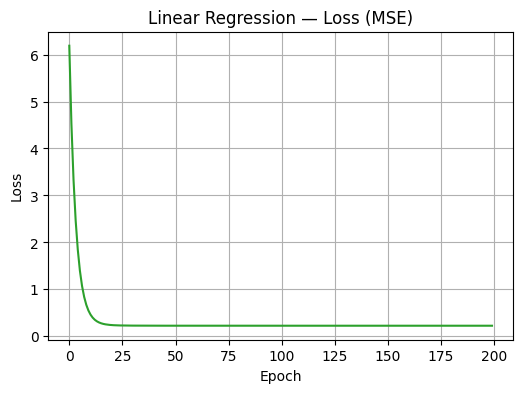

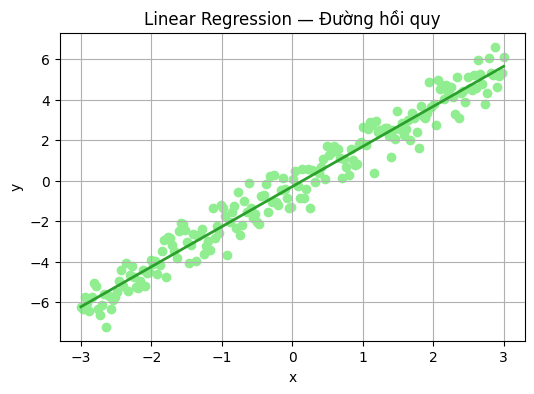

In [2]:
def train_linear_regression(x, y, lr=0.05, epochs=200):
    w, b = 0.0, 0.0
    history = []
    for _ in range(epochs):
        residual = (w * x + b) - y
        history.append(0.5 * np.mean(residual ** 2))
        w -= lr * np.mean(residual * x)
        b -= lr * np.mean(residual)
    return w, b, history


rng = np.random.default_rng(0)
x_lin = np.linspace(-3, 3, 200)
y_lin = 2 * x_lin - 0.3 + 0.7 * rng.standard_normal(200)

w_lin, b_lin, hist_lin = train_linear_regression(x_lin, y_lin)
print(f"w = {w_lin:.3f} (thật: 2.0), b = {b_lin:.3f} (thật: -0.3)")

plot_loss(hist_lin, "Linear Regression — Loss (MSE)")

plt.figure()
plt.scatter(x_lin, y_lin, color="lightgreen")
plt.plot(x_lin, w_lin * x_lin + b_lin, color=GREEN, linewidth=2)
plt.title("Linear Regression — Đường hồi quy")
plt.xlabel("x"); plt.ylabel("y"); plt.grid(True)
plt.show()

## 2. Logistic Regression

Dùng cho phân loại nhị phân: dự đoán xác suất một điểm dữ liệu thuộc lớp 1 nhờ hàm sigmoid, sau đó đặt ngưỡng (thường 0.5) để ra nhãn 0/1. Loss là binary cross-entropy.

$$\sigma(z)=\frac{1}{1+e^{-z}},\quad z = w\cdot x + b$$

$$L = -\frac{1}{n}\sum_{i=1}^{n}\Big(y_i\ln \hat p_i + (1-y_i)\ln(1-\hat p_i)\Big)$$

**Vai trò của Gradient Descent:** tính độ thay đổi của cross-entropy theo tham số rồi cập nhật dần để xác suất dự đoán sát nhãn thật hơn. Gradient có dạng rất gọn:

$$\frac{\partial L}{\partial w} = \frac{1}{n}X^\top(\hat p - y), \qquad \frac{\partial L}{\partial b} = \frac{1}{n}\sum(\hat p_i - y_i)$$

Độ chính xác trên tập huấn luyện: 1.000


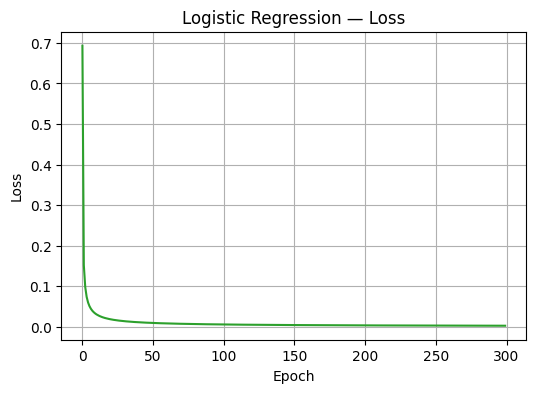

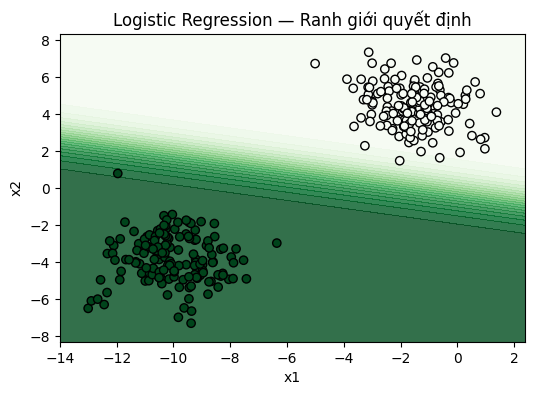

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def train_logistic(X, y, lr=0.2, epochs=300, eps=1e-12):
    w = np.zeros(X.shape[1])
    b = 0.0
    history = []
    for _ in range(epochs):
        p = sigmoid(X @ w + b)
        history.append(-np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)))
        w -= lr * (X.T @ (p - y)) / len(X)
        b -= lr * np.mean(p - y)
    return w, b, history


X_log, y_log = make_blobs(n_samples=300, centers=2, cluster_std=1.2, random_state=1)
w_log, b_log, hist_log = train_logistic(X_log, y_log)
acc = np.mean((sigmoid(X_log @ w_log + b_log) > 0.5) == y_log)
print(f"Độ chính xác trên tập huấn luyện: {acc:.3f}")

plot_loss(hist_log, "Logistic Regression — Loss")
plot_regions(lambda g: sigmoid(g @ w_log + b_log), X_log, y_log,
             "Logistic Regression — Ranh giới quyết định")

## 3. Softmax Regression

Mở rộng của logistic regression cho bài toán nhiều lớp: đầu ra là một phân phối xác suất trên $K$ lớp, lớp có xác suất cao nhất được chọn. Loss là categorical cross-entropy.

$$\hat p_{i,k}=\frac{e^{z_{i,k}}}{\sum_{j=1}^{K}e^{z_{i,j}}},\qquad L=-\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K}y_{i,k}\ln \hat p_{i,k}$$

- $z_{i,k}$: logit của lớp $k$ cho mẫu $i$
- $y_{i,k}$: nhãn one-hot

**Vai trò của Gradient Descent:** cập nhật ma trận trọng số để xác suất của lớp đúng tăng dần. Gradient: $\frac{1}{n}X^\top(\hat P - Y)$.

Độ chính xác: 0.8844444444444445


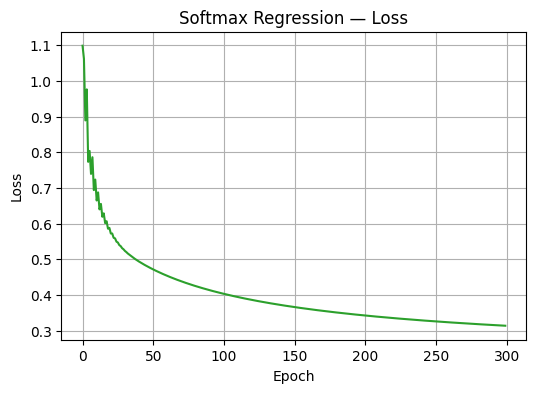

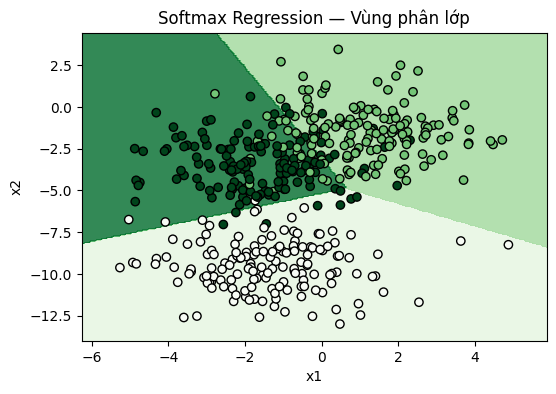

In [4]:
def softmax(z):
    shifted = z - z.max(axis=1, keepdims=True)   # ổn định số học, không sửa mảng gốc
    e = np.exp(shifted)
    return e / e.sum(axis=1, keepdims=True)


def one_hot(y, k):
    out = np.zeros((len(y), k))
    out[np.arange(len(y)), y] = 1.0
    return out


def train_softmax(X, y, k, lr=0.2, epochs=300, eps=1e-12):
    W = np.zeros((X.shape[1], k))
    b = np.zeros(k)
    Y = one_hot(y, k)
    history = []
    for _ in range(epochs):
        P = softmax(X @ W + b)
        history.append(-np.sum(Y * np.log(P + eps)) / len(X))
        G = (P - Y) / len(X)
        W -= lr * (X.T @ G)
        b -= lr * G.sum(axis=0)
    return W, b, history


K3 = 3
X_sm, y_sm = make_blobs(n_samples=450, centers=K3, cluster_std=1.5, random_state=2)
W_sm, b_sm, hist_sm = train_softmax(X_sm, y_sm, K3)
print("Độ chính xác:", np.mean(np.argmax(softmax(X_sm @ W_sm + b_sm), axis=1) == y_sm))

plot_loss(hist_sm, "Softmax Regression — Loss")
plot_regions(lambda g: np.argmax(softmax(g @ W_sm + b_sm), axis=1), X_sm, y_sm,
             "Softmax Regression — Vùng phân lớp", levels=K3)

## 4. Neural Network (1 hidden layer)

Mạng nơ-ron có một lớp ẩn học được các mẫu phi tuyến mà mô hình tuyến tính không bắt được, nhờ hàm kích hoạt như ReLU. Lớp đầu ra dùng softmax, huấn luyện bằng backpropagation.

- Lớp ẩn: $a^{(1)}=\text{ReLU}(W^{(1)}x+b^{(1)})$
- Lớp ra: $\hat y=\text{softmax}(W^{(2)}a^{(1)}+b^{(2)})$
- Loss: $L=-\sum_{k=1}^{K}y_k\ln\hat y_k$

**Vai trò của Gradient Descent:** backpropagation tính gradient cho từng lớp, Gradient Descent dùng các gradient đó để cập nhật trọng số qua từng mini-batch.

Độ chính xác: 0.9844444444444445


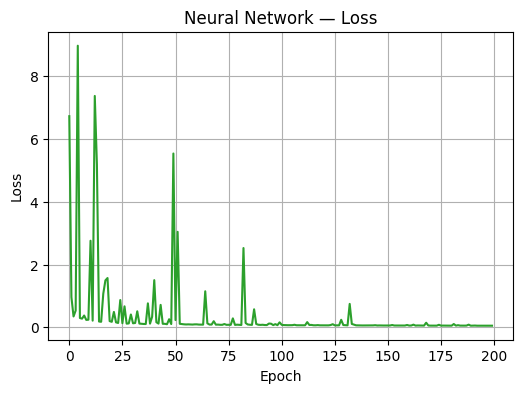

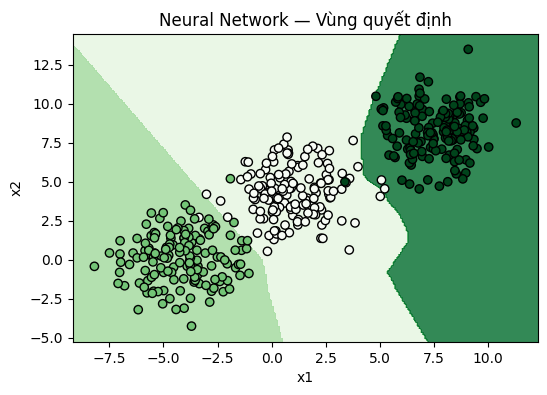

In [5]:
def train_mlp(X, y, k, hidden=32, lr=0.05, epochs=200, batch_size=64, seed=3, eps=1e-12):
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    W1 = rng.standard_normal((d, hidden)) * np.sqrt(2 / d)   # khởi tạo He
    b1 = np.zeros(hidden)
    W2 = rng.standard_normal((hidden, k)) * np.sqrt(2 / hidden)
    b2 = np.zeros(k)
    Y_all = one_hot(y, k)
    history = []

    for _ in range(epochs):
        order = rng.permutation(len(X))
        for start in range(0, len(X), batch_size):
            ids = order[start:start + batch_size]
            xb, Yb = X[ids], Y_all[ids]

            # forward
            z1 = xb @ W1 + b1
            a1 = np.maximum(0, z1)
            P = softmax(a1 @ W2 + b2)

            # backward
            d_logits = (P - Yb) / len(ids)
            dW2, db2 = a1.T @ d_logits, d_logits.sum(axis=0)
            dz1 = (d_logits @ W2.T) * (z1 > 0)
            dW1, db1 = xb.T @ dz1, dz1.sum(axis=0)

            # cập nhật
            W1 -= lr * dW1; b1 -= lr * db1
            W2 -= lr * dW2; b2 -= lr * db2

        P_full = softmax(np.maximum(0, X @ W1 + b1) @ W2 + b2)
        history.append(-np.sum(Y_all * np.log(P_full + eps)) / len(X))

    return (W1, b1, W2, b2), history


def mlp_predict(params, X):
    W1, b1, W2, b2 = params
    return np.argmax(softmax(np.maximum(0, X @ W1 + b1) @ W2 + b2), axis=1)


X_nn, y_nn = make_blobs(n_samples=450, centers=3, cluster_std=1.5, random_state=3)
params_nn, hist_nn = train_mlp(X_nn, y_nn, 3)
print("Độ chính xác:", np.mean(mlp_predict(params_nn, X_nn) == y_nn))

plot_loss(hist_nn, "Neural Network — Loss")
plot_regions(lambda g: mlp_predict(params_nn, g), X_nn, y_nn,
             "Neural Network — Vùng quyết định", levels=3)

## 5. Support Vector Machine

SVM tìm siêu phẳng phân tách các lớp sao cho lề (margin) giữa hai lớp lớn nhất; các support vector là những điểm quyết định vị trí ranh giới. Hinge loss phạt các điểm bị phân loại sai hoặc nằm quá gần ranh giới.

$$L=\frac{1}{2}\|w\|^2 + C\cdot\frac{1}{n}\sum_{i=1}^{n}\max\big(0,\,1-y_i(w\cdot x_i+b)\big),\qquad y_i\in\{-1,+1\}$$

**Vai trò của Gradient Descent:** giảm hàm mục tiêu trên bằng (sub)gradient; chỉ những điểm có margin < 1 mới đóng góp vào gradient của hinge loss.

Độ chính xác: 0.92


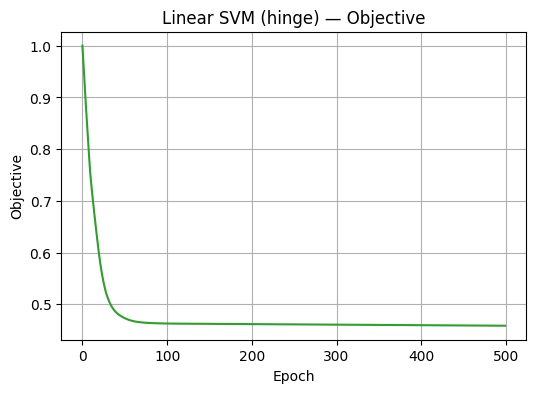

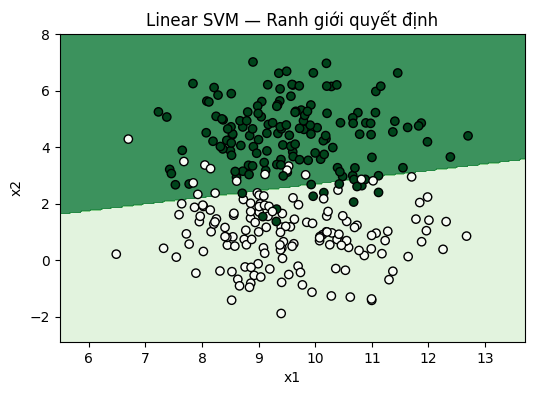

In [6]:
def train_linear_svm(X, y_pm, lr=0.01, C=1.0, epochs=500):
    w = np.zeros(X.shape[1])
    b = 0.0
    history = []
    n = len(X)
    for _ in range(epochs):
        margin = y_pm * (X @ w + b)
        violating = margin < 1
        history.append(0.5 * w @ w + C * np.mean(np.maximum(0, 1 - margin)))

        grad_w = w - (C / n) * (X[violating].T @ y_pm[violating])
        grad_b = -(C / n) * y_pm[violating].sum()
        w -= lr * grad_w
        b -= lr * grad_b
    return w, b, history


X_svm, y01 = make_blobs(n_samples=300, centers=2, cluster_std=1.2, random_state=4)
y_svm = 2 * y01 - 1                       # đổi nhãn {0,1} -> {-1,+1}
w_svm, b_svm, hist_svm = train_linear_svm(X_svm, y_svm)
print("Độ chính xác:", np.mean(np.sign(X_svm @ w_svm + b_svm) == y_svm))

plot_loss(hist_svm, "Linear SVM (hinge) — Objective", ylabel="Objective")
plot_regions(lambda g: (g @ w_svm + b_svm > 0).astype(int), X_svm, y01,
             "Linear SVM — Ranh giới quyết định", levels=2)

## 6. Matrix Factorization

Dùng trong hệ gợi ý: phân rã ma trận đánh giá user–item thành hai ma trận nhân tố ẩn nhỏ hơn, đại diện cho sở thích của người dùng và đặc điểm của sản phẩm, rồi dùng chúng để dự đoán các đánh giá còn thiếu.

$$R\approx PQ^\top,\qquad L=\sum_{(i,j)\in\Omega}\big(R_{ij}-P_iQ_j^\top\big)^2+\lambda\big(\|P\|^2+\|Q\|^2\big)$$

- $\Omega$: tập các cặp (user, item) đã quan sát được
- $\lambda$: hệ số regularization

**Vai trò của Gradient Descent:** với mỗi đánh giá đã biết, cập nhật vector nhân tố của user và item để giảm chênh lệch giữa dự đoán và giá trị thật (ở đây dùng SGD theo từng điểm).

RMSE trên các ô chưa quan sát: 0.804


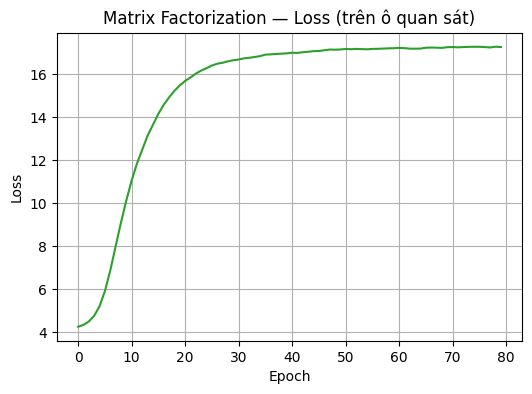

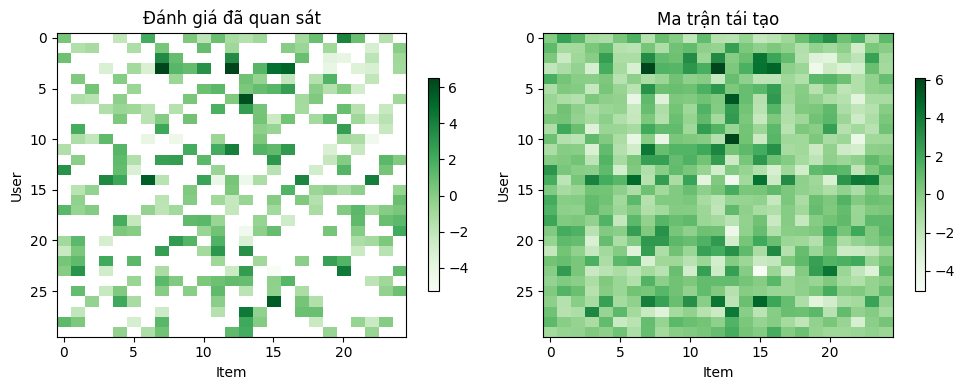

In [7]:
def train_matrix_factorization(R, mask, k=4, lr=0.01, reg=0.1, epochs=80, seed=5):
    rng = np.random.default_rng(seed)
    n_users, n_items = R.shape
    P = 0.1 * rng.standard_normal((n_users, k))
    Q = 0.1 * rng.standard_normal((n_items, k))
    observed = np.argwhere(mask)
    history = []

    for _ in range(epochs):
        rng.shuffle(observed)
        for i, j in observed:
            err = R[i, j] - P[i] @ Q[j]
            p_old = P[i].copy()
            P[i] += lr * (2 * err * Q[j] - 2 * reg * P[i])
            Q[j] += lr * (2 * err * p_old - 2 * reg * Q[j])

        diff = mask * (R - P @ Q.T)
        history.append((diff ** 2).sum() / mask.sum() + reg * (np.sum(P ** 2) + np.sum(Q ** 2)))
    return P, Q, history


rng = np.random.default_rng(5)
n_users, n_items, true_k = 30, 25, 4
R_true = rng.standard_normal((n_users, true_k)) @ rng.standard_normal((n_items, true_k)).T
mask_obs = rng.random((n_users, n_items)) < 0.4            # chỉ ~40% đánh giá được biết
R_obs = np.where(mask_obs, R_true + 0.5 * rng.standard_normal(R_true.shape), 0.0)

P_mf, Q_mf, hist_mf = train_matrix_factorization(R_obs, mask_obs)
R_hat = P_mf @ Q_mf.T
rmse_hidden = np.sqrt(np.mean((R_hat[~mask_obs] - R_true[~mask_obs]) ** 2))
print(f"RMSE trên các ô chưa quan sát: {rmse_hidden:.3f}")

plot_loss(hist_mf, "Matrix Factorization — Loss (trên ô quan sát)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in zip(
    axes,
    [np.where(mask_obs, R_obs, np.nan), R_hat],
    ["Đánh giá đã quan sát", "Ma trận tái tạo"],
):
    im = ax.imshow(data, aspect="auto", cmap="Greens")
    ax.set_title(title); ax.set_xlabel("Item"); ax.set_ylabel("User")
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

## Tài liệu tham khảo

- Bài gốc: *Gradient Descent Algorithm in Machine Learning* — GeeksforGeeks
- Notebook chính thức của GfG: https://media.geeksforgeeks.org/wp-content/uploads/20260311114039143040/Gradient_descent_in_ml.ipynb